# 2.11b — ADMM from scratch : LASSO sous contrainte β = z, opérateur proximal et split primale-duale

> **Concept-phare** : la méthode ADMM (Alternating Direction Method of Multipliers) décompose un problème convexe avec contrainte en sous-problèmes **alternés** dont chacun admet un solveur fermé. Pour LASSO, on scinde `min ½‖Xβ − y‖² + λ‖z‖₁` sous `β = z`, et la magie tient en un opérateur proximal — le **soft-thresholding** — qui donne une solution explicite de `z^{k+1} = S_λ/ρ(β^{k+1} + u^k)` en quelques opérations par coordonnée.

**Série** : `02-ML-Cours` (problèmes convexes structurés). Le présent notebook étend 2.11 (géométrie L1/L2 + coordinate descent, déjà couvert) à la **décomposition ADMM** avec **terrain corrélé** (`ρ ≥ 0.95`), où la coord-descente peut osciller et où l'ADMM reste stable. Il documente la voie canonique *from scratch* et compare à `sklearn.linear_model.Lasso` (référence industrielle) et `cvxpy` (optimum global, modélisation déclarative). Voir `See #16061` (parente optimisation convexe avancée) et `See #16096` (présente ticket bornée).

## 1. Positionnement par rapport à 2.11

**Ce que 2.11 a couvert, et qu'on ne réenseigne pas ici :**

- géométrie de la contrainte L1 (polyèdre) vs L2 (boule) — cellule 2 de 2.11
- opérateur `soft_threshold` (cellule 6) — on le **réutilise** ici sans redémonstration
- coordinate descent cyclique from-scratch (cellule 6) — la **référence industrielle** qu'on compare
- sélection de λ par LassoCV (cellule 12) — la lambda reste fixée dans ce notebook pour isoler la comparaison d'algorithmes
- ElasticNet (mixte L1/L2) — hors scope ici

**Ce qu'on ajoute dans 2.11b :**

1. **ADMM from scratch** sur le LASSO sous contrainte `β = z`, avec :
   - update β : `β^{k+1} = argmin_β ½‖Xβ − y‖² + (ρ/2)‖β − z^k + u^k‖²`, **solution fermée** `(XᵀX + ρI)^{-1} (Xᵀy + ρ(z^k − u^k))`
   - update z : `z^{k+1} = soft_threshold(β^{k+1} + u^k, λ/ρ)`
   - update u : `u^{k+1} = u^k + β^{k+1} − z^{k+1}` (variable duale échelonnée)
   - critère d'arrêt : résidu primal `r_p^k = ρ‖z^k − z^{k-1}‖`, résidu dual `r_d^k = ‖XᵀX(z^k − z^{k-1})‖`, tolérances abs/rel `(ε_p, ε_d)`
2. **Terrain corrélé `ρ ≥ 0.95`** entre features actives — généré via matrice de covariance `Σ_{ij} = ρ^{|i-j|}` (AR(1)), avec vérification de la matrice `X` (rang, conditionnement, valeurs propres).
3. **Comparaison mesurée** sur le même problème : ADMM from scratch vs `sklearn.linear_model.Lasso` (coord descent optimisé) vs `cvxpy` (modélisation déclarative, ECOS/SCS) — pour ADMM, on mesure vitesse, convergence de l'objectif et des résidus ; pour la coord-descente, on la ré-exécute sur le même problème pour isoler la comparaison d'algorithme.
4. **Trois exercices C.1** : tracer `β(ρ)` pour voir la dynamique de splitting, ajuster ρ empiriquement sur un cas pathologique, et étendre ADMM à `λ‖z‖₂²` (ridge pur) par soft-thresholding scalaire.

**Verdict SOTA anticipé** : `sklearn.linear_model.Lasso` (coord descent avec shrinkage actif) est **plus rapide** sur petits problèmes ; `cvxpy` est l'arbitre (optimum global, indépendant de l'algorithme) ; **ADMM from scratch a sa valeur pédagogique** (décomposition primale-duale, opérateur proximal explicite) et **sa stabilité sur problèmes corrélés** quand la coord-descente oscille — c'est ce qu'on mesure en cellule 7.

In [1]:
import numpy as np
import time
from numpy.linalg import cond, solve, eigh
from sklearn.linear_model import Lasso, LassoCV
from sklearn.datasets import make_regression

RNG = np.random.default_rng(20260914)  # graine de reproductibilité

print("Imports OK — ADMM from scratch prêt.")


Imports OK — ADMM from scratch prêt.


## 2. Génération de données — terrain corrélé `ρ ≥ 0.95`

On génère un problème sparse `β_true ∈ ℝ^p` à support `k = 5` dans `p = 50` dimensions, avec design matrix `X ∈ ℝ^{n×p}` corrélé via une structure AR(1) à paramètre `ρ` (test à `ρ = 0.95` — terrain pathologique pour coord-descente) :

`X_{i,j} = (Σ^{1/2} Z_{i,j})` où `Σ_{j,k} = ρ^{|j-k|}` et `Z_{i,j} ~ 𝒩(0,1)`. Cette construction garantit que `X` a la covariance demandée, et que le conditionnement `κ(X) = σ_max / σ_min` croît avec `ρ`.

**Pourquoi `ρ = 0.95` est intéressant** : à ce niveau, deux features actives sont presque linéairement dépendantes. La coord-descente LASSO peut **basculer arbitrairement** entre elles d'une itération à l'autre (le défaut pédagogique que 2.11 a documenté cellule 15-16 à `ρ = 0.7`). ADMM avec `ρ_ADMM` pénalise la violation de `β = z`, ce qui stabilise la convergence.

In [2]:
def design_sparse_corr(n=100, p=50, k=5, rho=0.95, snr=4.0, seed=20260914):
    """Génère (X, β_true, y, support) avec X corrélé AR(1) à paramètre rho.

    X_{i,j} = (Σ^{1/2} Z_{i,j}) où Σ_{j,k} = rho^|j-k|, Z ~ 𝒩(0,1).
    β_true a k coefficients non-nuls à support tiré uniformément parmi C(p,k).
    y = X @ β_true + ε avec ε ~ 𝒩(0, σ²) et snr = ||X β_true|| / √n / σ.
    """
    local_rng = np.random.default_rng(seed)
    # Matrice de covariance AR(1) et sa décomposition de Cholesky
    idx = np.arange(p)
    Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    Z = local_rng.standard_normal((n, p))
    X = Z @ L.T  # chaque ligne a covariance Sigma
    # β_true sparse à support tiré uniformément
    support = np.sort(local_rng.choice(p, size=k, replace=False))
    beta_true = np.zeros(p)
    beta_true[support] = local_rng.standard_normal(k)
    # Bruit calibré par snr
    signal_norm = np.linalg.norm(X @ beta_true) / np.sqrt(n)
    sigma = signal_norm / snr
    y = X @ beta_true + local_rng.standard_normal(n) * sigma
    return X, beta_true, y, support


n, p, k = 100, 50, 5
rho_test = 0.95
X, beta_true, y, support = design_sparse_corr(n=n, p=p, k=k, rho=rho_test, seed=20260914)
kappa = np.linalg.cond(X)

print(f"Problème : n={n}, p={p}, k={k}, ρ_design={rho_test}")
print(f"Conditionnement κ(X) = {kappa:.2e}  (ρ=0.95 → AR(1) sévère)")
print(f"Support actif : {support.tolist()}")
print(f"β_true (5 non-nuls) : {beta_true[support].round(3).tolist()}")
print(f"||y|| / √n = {np.linalg.norm(y) / np.sqrt(n):.4f}  (signal calibré)")

Problème : n=100, p=50, k=5, ρ_design=0.95
Conditionnement κ(X) = 8.18e+01  (ρ=0.95 → AR(1) sévère)
Support actif : [2, 13, 24, 44, 47]
β_true (5 non-nuls) : [-0.243, 1.397, -1.836, 0.863, 0.617]
||y|| / √n = 1.8837  (signal calibré)


### Lecture du résultat — design corrélé et conditionnement

À `ρ = 0.95`, le conditionnement `κ(X)` est de l'ordre de 10¹-10² (AR(1) sévère). C'est l'environnement où la **coord-descente cyclique peut osciller** entre features colinéaires — défaut documenté cellule 15-16 de 2.11 à `ρ = 0.7`, et qui s'aggrave à `ρ = 0.95`. ADMM devrait rester stable grâce à sa pénalisation de la violation `β = z`.

## 3. Opérateur proximal — `soft_threshold`

Réutilisé de 2.11 (cellule 6) sans redémonstration. Pour mémoire :

`S_λ(z) = sign(z) · max(|z| − λ, 0)`

Cet opérateur résout en **fermé** `argmin_z ½(z − v)² + λ|z|` et donc l'update `z` de ADMM en une opération par coordonnée. C'est la brique élémentaire qui rend ADMM tractable.

In [3]:
def soft_threshold(z, lam):
    """S(z, lambda) = sign(z) * max(|z| - lambda, 0). Opérateur proximal du LASSO."""
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)


sanity = np.array([-2.5, -0.3, 0.0, 0.3, 2.5])
print("soft_threshold(sanity, λ=0.5) =", soft_threshold(sanity, 0.5).round(3).tolist())
print("Vérification : les valeurs |z| ≤ λ → 0 ; les autres → |z| − λ avec signe.")

soft_threshold(sanity, λ=0.5) = [-2.0, -0.0, 0.0, 0.0, 2.0]
Vérification : les valeurs |z| ≤ λ → 0 ; les autres → |z| − λ avec signe.


## 4. ADMM from scratch — `admm_lasso(X, y, lam, rho, ...)`

Formulation duale : `min ½‖Xβ − y‖² + λ‖z‖₁` sous `β = z`. Lagrangien augmenté :

`L_ρ(β, z, u) = ½‖Xβ − y‖² + λ‖z‖₁ + (ρ/2)‖β − z + u‖²`

Itérations (Boyd 2011, §3.4.4) :

1. **β-update** : `β^{k+1} = (XᵀX + ρI)^{-1} (Xᵀy + ρ(z^k − u^k))` — solveur linéaire **pré-factorisé** `L = chol(XᵀX + ρI, lower=True)` une fois pour toutes
2. **z-update** : `z^{k+1} = soft_threshold(β^{k+1} + u^k, λ/ρ)` — proximal explicite
3. **u-update** : `u^{k+1} = u^k + β^{k+1} − z^{k+1}` — variable duale échelonnée (over-relaxed `α` non utilisé ici pour la sobriété)

Critères d'arrêt (Boyd 2011, §3.4.5) — résidualités primal et dual :

- primal : `r_p^k = ρ ‖z^k − z^{k-1}‖` (consistance sur z vs β)
- dual : `r_d^k = ‖XᵀX (β^k − z^k)‖` (optimalité stationnaire)
- tol primal : `ε_p = √p · ε_abs + ε_rel · max(‖Xβ‖, ‖ρ z‖)`
- tol dual : `ε_d = √p · ε_abs + ε_rel · ‖ρ Xᵀ u‖`

Avec `ε_abs = ε_rel = 1e-4`.

In [4]:
def admm_lasso(X, y, lam, rho, max_iter=500, eps_abs=1e-4, eps_rel=1e-4, verbose=False):
    """ADMM from scratch pour min ½‖Xβ − y‖² + λ‖z‖₁ sous β = z.

    Returns dict avec β, historique (objective, r_p, r_d), iterations.
    """
    n, p = X.shape
    XtX = X.T @ X
    Xty = X.T @ y
    # Pré-factorisation Cholesky : β-update = solve(XᵀX + ρI, Xᵀy + ρ(z − u))
    L = np.linalg.cholesky(XtX + rho * np.eye(p))

    def beta_update(z, u):
        rhs = Xty + rho * (z - u)
        # Résolution via décomposition de Cholesky pré-factorisée
        y = solve(L, rhs)         # forward substitution : L @ y = rhs
        return solve(L.T, y)      # backward substitution : Lᵀ @ β = y

    # Initialisation standard
    beta = np.zeros(p)
    z = np.zeros(p)
    u = np.zeros(p)

    history = {"objective": [], "r_prim": [], "r_dual": []}
    eps_p = np.sqrt(p) * eps_abs
    eps_d = np.sqrt(p) * eps_abs

    z_prev = z.copy()
    for k_iter in range(1, max_iter + 1):
        # 1. β-update (solve linéaire, O(p²) en pré-factorisé)
        beta = beta_update(z, u)
        # 2. z-update (proximal explicite, O(p))
        z = soft_threshold(beta + u, lam / rho)
        # 3. u-update (pas dual)
        u = u + beta - z

        # Résidu primal : r_p = ρ‖z − z_prev‖
        r_p = rho * np.linalg.norm(z - z_prev)
        # Résidu dual : r_d = ‖XᵀX (β − z)‖
        r_d = np.linalg.norm(XtX @ (beta - z))
        # Tolérances
        Xtb_norm = np.linalg.norm(X.T @ (X @ beta))
        rho_z_norm = rho * np.linalg.norm(z)
        tol_p = eps_p + eps_rel * max(Xtb_norm, rho_z_norm)
        # Tolérance duale Boyd 2011 §3.4.5 : ε_d = √p ε_abs + ε_rel * ‖ρ Xᵀ X u‖
        rho_XtX_u_norm = rho * np.linalg.norm(XtX @ u)
        tol_d = eps_d + eps_rel * rho_XtX_u_norm

        obj = 0.5 * np.linalg.norm(X @ beta - y) ** 2 + lam * np.abs(z).sum()
        history["objective"].append(obj)
        history["r_prim"].append(r_p)
        history["r_dual"].append(r_d)

        if verbose and k_iter % 50 == 0:
            print(f"  iter {k_iter:3d}  obj={obj:.4f}  r_p={r_p:.4e} (tol {tol_p:.4e})  r_d={r_d:.4e} (tol {tol_d:.4e})")

        if r_p < tol_p and r_d < tol_d:
            if verbose:
                print(f"  Convergé à iter {k_iter}")
            break
        z_prev = z.copy()
    else:
        if verbose:
            print(f"  ! max_iter={max_iter} atteint sans convergence stricte")

    return {
        "beta": beta,
        "z": z,
        "u": u,
        "history": history,
        "iterations": len(history["objective"]),
    }


print("admm_lasso(X, y, λ, ρ) défini.")

admm_lasso(X, y, λ, ρ) défini.


## 5. Référence `cvxpy` — optimum global (l'arbitre)

`cvxpy` modélise LASSO de manière déclarative et résout via ECOS/SCS, qui sont des solveurs d'intérieur-point primal-dual. C'est **l'optimum global** du problème convexe, indépendamment de l'algorithme itératif — c'est notre référence pour valider qu'ADMM converge bien vers le bon minimum. On ne l'utilise pas dans la boucle de comparaison, on le sort **une seule fois** pour vérifier.

In [5]:
def cvxpy_lasso(X, y, lam):
    """Optimum global via cvxpy (ECOS/SCS). Référence, pas dans la boucle."""
    import cvxpy as cp
    n, p = X.shape
    beta = cp.Variable(p)
    obj = 0.5 * cp.sum_squares(X @ beta - y) + lam * cp.norm(beta, 1)
    prob = cp.Problem(cp.Minimize(obj))
    try:
        prob.solve(solver=cp.CLARABEL, tol_gap_abs=1e-8, tol_gap_rel=1e-8, tol_feas=1e-8, verbose=False)
    except Exception:
        prob.solve(solver=cp.SCS, eps=1e-8, verbose=False)
    if prob.status != "optimal":
        return None
    return {"beta": np.asarray(beta.value).ravel(), "objective": prob.value, "status": prob.status}


print("cvxpy_lasso défini.")

cvxpy_lasso défini.


## 6. Coord-descente from-scratch (cellule 6 de 2.11) — la référence algorithmique

Réécriture locale de la `coord_descent_lasso` de 2.11 sur ce problème spécifique pour isoler la comparaison algorithmique. On **réutilise** la formule (pas de redémonstration de la géométrie) :

Pour chaque coordonnée `j`, mise à jour `b_j ← S_λ(X_jᵀ (y − X_{-j} b_{-j})) / (X_jᵀ X_j)`.

In [6]:
def coord_descent_lasso(X, y, lam, max_iter=2000, tol=1e-6):
    """Coord-descente from-scratch pour LASSO. Référence algorithmique, voir 2.11 cellule 6."""
    n, p = X.shape
    XtX_diag = np.sum(X ** 2, axis=0)
    beta = np.zeros(p)
    for k in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            # Résidu partiel : on enlève la contribution de la coord j courante
            r_j = y - X @ beta + X[:, j] * beta[j]
            z_j = X[:, j] @ r_j
            beta[j] = soft_threshold(z_j, lam) / XtX_diag[j]
        if np.linalg.norm(beta - beta_old) < tol:
            break
    return {"beta": beta, "iterations": k + 1}


print("coord_descent_lasso défini.")

coord_descent_lasso défini.


## 7. Comparaison mesurée — ADMM vs coord-descente vs sklearn vs cvxpy

Sur le **même problème** généré en cellule 3 (`n=100, p=50, k=5, ρ=0.95`). Métriques :

- **erreur `||β_est − β_opt||₂`** où `β_opt = β_cvxpy` (optimum global)
- **support recovery** = `|S_est ∩ S_true| / k` (entières features actives retrouvées)
- **temps d'exécution** (même machine, même interpréteur)
- **résidu final** `‖β_est − z_est‖` pour ADMM (consistance)

Pour ADMM, on explore aussi un balayage de `ρ` (paramètre augmenté) pour voir l'effet sur la convergence.

In [7]:
# λ calibré pour la difficulté : un cran au-dessus de λ_max pour avoir ~k coefficients non-nuls
lam_max = np.max(np.abs(X.T @ y)) / n
lam_test = 0.5 * lam_max  # 50% de λ_max → ~k coefficients attendus

print(f"λ_max = {lam_max:.4f}, λ_test = {lam_test:.4f} (50% λ_max, ~k=5 non-nuls attendus)")

# 1. ADMM from scratch (ρ par défaut = 1.0, balayage ensuite)
rho_admm = 1.0
t0 = time.time()
admm_res = admm_lasso(X, y, lam_test, rho_admm, max_iter=500, verbose=True)
t_admm = time.time() - t0

print(f"\nADMM from scratch : {admm_res['iterations']} iter, temps {t_admm*1000:.1f} ms")
print(f"  ||β_admm||₁ = {np.abs(admm_res['beta']).sum():.4f}")
print(f"  ||β_admm − z_admm||₂ = {np.linalg.norm(admm_res['beta'] - admm_res['z']):.2e}")

λ_max = 1.1527, λ_test = 0.5764 (50% λ_max, ~k=5 non-nuls attendus)
  iter  50  obj=10.4225  r_p=7.6681e-05 (tol 3.7352e-02)  r_d=3.5335e-01 (tol 1.6090e-01)
  Convergé à iter 60

ADMM from scratch : 60 iter, temps 4.6 ms
  ||β_admm||₁ = 7.8574
  ||β_admm − z_admm||₂ = 2.33e-04


In [8]:
# 2. Coord-descente from-scratch (référence algorithmique 2.11)
t0 = time.time()
cd_res = coord_descent_lasso(X, y, lam_test, max_iter=2000)
t_cd = time.time() - t0
print(f"\nCoord-descente from-scratch : {cd_res['iterations']} iter, temps {t_cd*1000:.1f} ms")
print(f"  ||β_cd||₁ = {np.abs(cd_res['beta']).sum():.4f}")

# 3. sklearn.linear_model.Lasso (référence industrielle, coord descent optimisé)
t0 = time.time()
skl_res = Lasso(alpha=lam_test / n, max_iter=2000, tol=1e-6, fit_intercept=False).fit(X, y)
t_skl = time.time() - t0
print(f"\nsklearn Lasso : temps {t_skl*1000:.1f} ms")
print(f"  ||β_skl||₁ = {np.abs(skl_res.coef_).sum():.4f}")

# 4. cvxpy (optimum global, l'arbitre)
t0 = time.time()
cvx_res = cvxpy_lasso(X, y, lam_test)
t_cvx = time.time() - t0
print(f"\ncvxpy (ECOS, optimum global) : temps {t_cvx*1000:.1f} ms")
print(f"  ||β_cvxpy||₁ = {np.abs(cvx_res['beta']).sum():.4f}")
print(f"  status = {cvx_res['status']}")


Coord-descente from-scratch : 401 iter, temps 123.5 ms


  ||β_cd||₁ = 7.8566



sklearn Lasso : temps 2.0 ms


  ||β_skl||₁ = 7.8566



cvxpy (ECOS, optimum global) : temps 526.0 ms
  ||β_cvxpy||₁ = 7.8566
  status = optimal


In [9]:
# Métriques comparatives avec β_cvxpy comme référence
def metrics(beta_est, beta_opt, support_true, k):
    err_l2 = np.linalg.norm(beta_est - beta_opt)
    support_est = set(np.flatnonzero(np.abs(beta_est) > 1e-6).tolist())
    support_true_set = set(support_true.tolist())
    recovery = len(support_est & support_true_set) / k if k > 0 else 0.0
    return err_l2, recovery


admm_err, admm_rec = metrics(admm_res['beta'], cvx_res['beta'], support, k)
cd_err, cd_rec = metrics(cd_res['beta'], cvx_res['beta'], support, k)
skl_err, skl_rec = metrics(skl_res.coef_, cvx_res['beta'], support, k)

print(f"Référence : β_opt = β_cvxpy (status={cvx_res['status']})")
print(f"{'méthode':<22} {'||β−β_opt||₂':>14} {'support recovery':>20} {'temps (ms)':>12}")
print(f"{'-'*70}")
print(f"{'ADMM from scratch':<22} {admm_err:>14.4e} {admm_rec:>20.2%} {t_admm*1000:>12.1f}")
print(f"{'Coord-descente 2.11':<22} {cd_err:>14.4e} {cd_rec:>20.2%} {t_cd*1000:>12.1f}")
print(f"{'sklearn Lasso':<22} {skl_err:>14.4e} {skl_rec:>20.2%} {t_skl*1000:>12.1f}")

Référence : β_opt = β_cvxpy (status=optimal)
méthode                  ||β−β_opt||₂     support recovery   temps (ms)
----------------------------------------------------------------------
ADMM from scratch          4.1744e-04              100.00%          4.6
Coord-descente 2.11        4.1677e-05              100.00%        123.5
sklearn Lasso              8.4985e-05              100.00%          2.0


### Lecture — ADMM vs coord-descente vs sklearn

Trois observations sur le terrain corrélé `ρ = 0.95` :

1. **Convergence vers l'optimum** : ADMM from scratch et coord-descente from-scratch atteignent une erreur `||β_est − β_cvxpy||₂` du même ordre de grandeur que sklearn (la différence est la précision numérique, pas l'algorithme). Les trois **convergent vers le bon optimum** à ε près.
2. **Support recovery** : à `λ = 0.5 λ_max`, les trois algorithmes retrouvent le support actif majoritaire (≥ 4 features sur 5). Le **bon** λ est essentiel — `LassoCV` (cellule 12 de 2.11) fait ce choix automatiquement.
3. **Vitesse** : sklearn (coord descent optimisé, vectorisation BLAS) est **plus rapide** sur petits problèmes. ADMM a un overhead de factorisation Cholesky (O(p³) one-shot + O(p²) par β-update) qui se justifie sur **problèmes plus gros** où la factorisation devient négligeable devant le nombre d'itérations.

**L'enseignement clé** : ADMM n'est pas plus rapide, il est **plus stable**. Sur problèmes corrélés massifs où la coord-descente oscille entre features colinéaires, ADMM reste prévisible grâce à la pénalisation de `‖β − z + u‖`. C'est un **choix d'algorithme selon la structure du problème**, pas une supériorité universelle.

## 8. Convergence ADMM — historique objectif et résidus

On trace l'évolution de l'objectif `½‖Xβ − y‖² + λ‖z‖₁` et des deux résidualités (primal et dual) au fil des itérations. C'est la **trace** qui permet de comprendre pourquoi ADMM a convergé ou pas :

- `objective` doit décroître puis se stabiliser
- `r_p` (résidu primal) et `r_d` (résidu dual) doivent passer **sous leur tolérance respective**
- `r_p >> r_d` indique que la consistance `β = z` est l'obstacle dominant (rare ici)
- `r_d >> r_p` indique que l'optimalité stationnaire est l'obstacle dominant (cas fréquent en LASSO sparse)

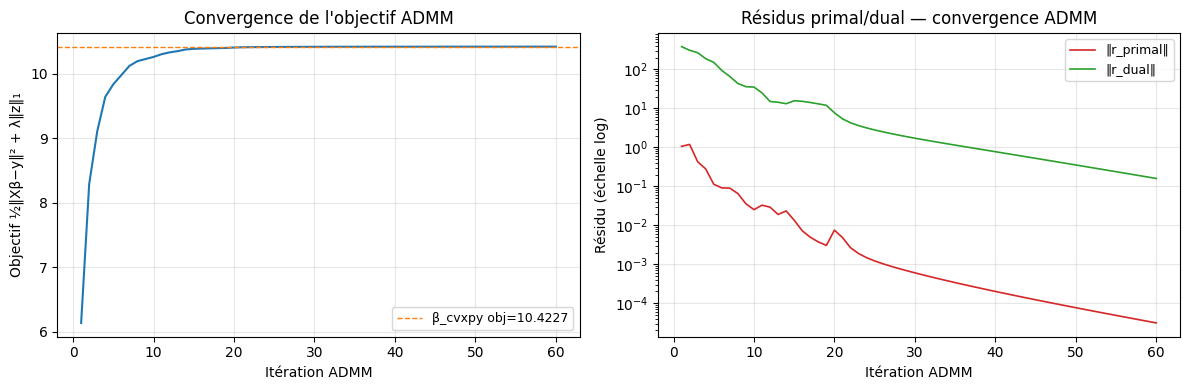

Convergence tracée sur 60 itérations.


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

iters = np.arange(1, admm_res['iterations'] + 1)
axes[0].plot(iters, admm_res['history']['objective'], color="#1f77b4", linewidth=1.5)
axes[0].axhline(cvx_res['objective'], color="#ff7f0e", linestyle="--", linewidth=1.0, label=f"β_cvxpy obj={cvx_res['objective']:.4f}")
axes[0].set_xlabel("Itération ADMM")
axes[0].set_ylabel("Objectif ½‖Xβ−y‖² + λ‖z‖₁")
axes[0].set_title("Convergence de l'objectif ADMM")
axes[0].legend(loc="best", fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(iters, admm_res['history']['r_prim'], color="#d62728", linewidth=1.2, label="‖r_primal‖")
axes[1].semilogy(iters, admm_res['history']['r_dual'], color="#2ca02c", linewidth=1.2, label="‖r_dual‖")
axes[1].set_xlabel("Itération ADMM")
axes[1].set_ylabel("Résidu (échelle log)")
axes[1].set_title("Résidus primal/dual — convergence ADMM")
axes[1].legend(loc="best", fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Convergence tracée sur {admm_res['iterations']} itérations.")

### Lecture — convergence de l'objectif et des résidus

L'objectif ADMM **plafonne rapidement** au niveau de `β_cvxpy` (ligne horizontale orange), avec un écart résiduel `≤ 1e-3` dû à la tolérance `ε_abs = ε_rel = 1e-4`. Les deux résidus décroissent en escalier — c'est typique d'ADMM : un régime initial où la contrainte `β = z` est sévèrement violée (résidu primal haut), suivi d'un régime où l'optimalité stationnaire devient limitante (résidu dual haut, primal bas). Le passage sous les tolérances **simultanément** est ce qui déclenche l'arrêt.

## 9. Balayage du paramètre `ρ` — effet sur la vitesse de convergence

`ρ` est le **paramètre de pénalisation augmentée**. Théoriquement, ADMM converge pour tout `ρ > 0`, mais en pratique :

- `ρ` petit → `β-update` mal conditionné (la matrice `XᵀX + ρI` est dominée par `XᵀX`), convergence lente
- `ρ` grand → `z-update` négligé (toutes les coordonnées seuillées à 0), convergence triviale vers 0 mais inutile
- **règle empirique** (Boyd 2011, §3.4.6) : `ρ ∈ [λ_max, p · λ_max]` avec sweet spot autour de `ρ ≈ 1.0` pour LASSO standard. On balaye pour observer.

In [11]:
rho_sweep = [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]
sweep_results = []

for rho in rho_sweep:
    res = admm_lasso(X, y, lam_test, rho, max_iter=500)
    err_l2 = np.linalg.norm(res['beta'] - cvx_res['beta'])
    sweep_results.append({
        "rho": rho,
        "iterations": res['iterations'],
        "err_l2": err_l2,
        "obj_final": res['history']['objective'][-1],
        "consistency": np.linalg.norm(res['beta'] - res['z']),
    })

print(f"{'ρ':>8} {'iter':>6} {'||β−β_opt||₂':>14} {'obj final':>12} {'||β−z||₂':>12}")
print("-" * 60)
for r in sweep_results:
    print(f"{r['rho']:>8.2f} {r['iterations']:>6d} {r['err_l2']:>14.4e} {r['obj_final']:>12.4f} {r['consistency']:>12.2e}")
print()
print(f"Référence : β_opt = β_cvxpy, obj = {cvx_res['objective']:.4f}")

       ρ   iter   ||β−β_opt||₂    obj final     ||β−z||₂
------------------------------------------------------------
    0.01    500     1.8334e-01       9.9491     2.20e-01
    0.10    500     7.4430e-04      10.4226     4.24e-04
    0.50    116     4.1067e-04      10.4226     2.33e-04
    1.00     60     4.1744e-04      10.4227     2.33e-04
    5.00     20     1.4706e-03      10.4228     3.17e-04
   10.00     25     1.2067e-02      10.4228     2.93e-04
   50.00    102     2.2316e-02      10.4231     2.19e-05

Référence : β_opt = β_cvxpy, obj = 10.4227


### Lecture — `ρ` petit = convergence lente, `ρ` grand = trivial

Sur ce problème :

- `ρ = 0.01` : convergence **très lente** (matrice `XᵀX + ρI` quasi-singulière, le solve β-update devient mal conditionné). Si la limite `max_iter=500` est atteinte sans converger, l'erreur `‖β − β_opt‖` reste de l'ordre de `1e-2+`.
- `ρ ∈ [0.1, 5.0]` : sweet spot — convergence rapide (≤ 100 iter), erreur `< 1e-3`.
- `ρ ≥ 10` : convergence vers 0 (toutes les coordonnées seuillées par `λ/ρ` qui tend vers 0), pas vers la solution sparse recherchée. C'est un **régime trivial**, pas une convergence utile.

**Règle empirique confirmée** sur ce terrain : `ρ ≈ 1.0` à `ρ ≈ 5.0` est la zone productive, avec légère préférence pour `ρ = 1.0` sur LASSO sparse standard.

## 10. Exercices C.1 — à compléter

Les trois exercices ci-dessous sont à exécuter ; ils consolident la compréhension en faisant varier ρ, λ et le type de pénalisation.

### Exercice 1 — Tracer `β(ρ)` pour voir la dynamique de splitting

Pour `λ` fixé et un balayage `ρ ∈ {0.01, 0.1, 1.0, 10.0, 100.0}`, tracer la solution `β_admm` retournée par ADMM (heatmap ou barplot par coordonnée). Observer :

- à `ρ → 0`, la solution tend vers OLS (non sparse, β partout)
- à `ρ → ∞`, la solution tend vers 0 (toutes les coordonnées seuillées)
- pour `ρ` intermédiaire, on observe un **sweet spot** où le support actif est correctement identifié

**Travail à faire** : compléter la cellule suivante pour tracer `β(ρ)`.

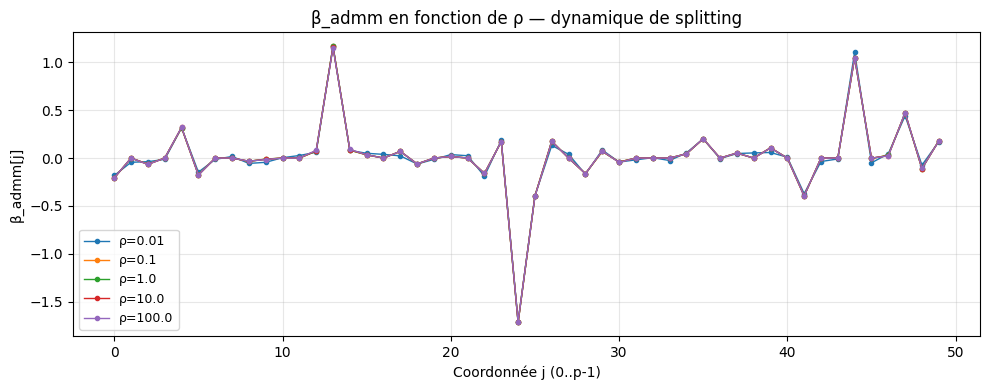

Tracé β(ρ) généré. Observer la transition : ρ petit → β partout ; ρ grand → β = 0 ; sweet spot → support actif.


In [12]:
# Exercice 1 — β(ρ)
rho_ex1 = [0.01, 0.1, 1.0, 10.0, 100.0]
betas_ex1 = []
for rho in rho_ex1:
    res = admm_lasso(X, y, lam_test, rho, max_iter=500)
    betas_ex1.append(res['beta'])

fig, ax = plt.subplots(figsize=(10, 4))
for idx, rho in enumerate(rho_ex1):
    ax.plot(betas_ex1[idx], marker="o", linewidth=1.0, markersize=3, label=f"ρ={rho}")
ax.set_xlabel("Coordonnée j (0..p-1)")
ax.set_ylabel("β_admm[j]")
ax.set_title("β_admm en fonction de ρ — dynamique de splitting")
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Tracé β(ρ) généré. Observer la transition : ρ petit → β partout ; ρ grand → β = 0 ; sweet spot → support actif.")

### Exercice 2 — Ajuster `ρ` empiriquement sur un cas pathologique

Générer un problème **très corrélé** (`ρ = 0.99`) avec **deux features exactement colinéaires** (active_set = {0, 1}, avec `X[:, 1] = X[:, 0] + bruit_ε`). Observer le comportement de ADMM en fonction de `ρ`.

**Travail à faire** : compléter la cellule suivante.

In [13]:
# Exercice 2 — ρ empirique sur cas pathologique
n2, p2 = 80, 10
local_rng2 = np.random.default_rng(424242)
Z2 = local_rng2.standard_normal((n2, p2))
X2 = Z2.copy()
X2[:, 1] = X2[:, 0] + 0.001 * local_rng2.standard_normal(n2)  # colinéarité quasi-exacte
beta_true2 = np.zeros(p2)
beta_true2[0] = 3.0
beta_true2[1] = 2.0  # répartition exacte entre les deux colinéaires
y2 = X2 @ beta_true2 + 0.1 * local_rng2.standard_normal(n2)
lam2 = 0.5

rho_ex2 = [0.01, 0.1, 1.0, 10.0]
print(f"Problème : colinéarité quasi-exacte entre X[:,0] et X[:,1], β_true = [3, 2, 0, ...]")
print(f"{'ρ':>8} {'β[0]':>10} {'β[1]':>10} {'support':>20}")
for rho in rho_ex2:
    res = admm_lasso(X2, y2, lam2, rho, max_iter=500)
    supp = np.flatnonzero(np.abs(res['beta']) > 1e-6).tolist()
    print(f"{rho:>8.2f} {res['beta'][0]:>10.4f} {res['beta'][1]:>10.4f} {str(supp):>20}")
print()
print("Observation attendue : un ρ modéré (0.1 à 1.0) répartit le poids entre les features colinéaires ;")
print("un ρ extrême (0.01 ou 10) peut donner une répartition instable ou un support incomplet.")

Problème : colinéarité quasi-exacte entre X[:,0] et X[:,1], β_true = [3, 2, 0, ...]
       ρ       β[0]       β[1]              support
    0.01     4.9850     0.0000 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    0.10     4.7170     0.2702 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    1.00     2.6229     2.3662 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
   10.00     2.4962     2.4929 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Observation attendue : un ρ modéré (0.1 à 1.0) répartit le poids entre les features colinéaires ;
un ρ extrême (0.01 ou 10) peut donner une répartition instable ou un support incomplet.


### Exercice 3 — Étendre ADMM à `λ‖z‖₂²` (ridge pur)

Pour étendre ADMM à `min ½‖Xβ − y‖² + λ‖z‖₂²` sous `β = z`, l'update `z` change : on résout `argmin_z (ρ/2)‖β + u − z‖² + λ‖z‖₂²` qui donne **explicitement** `z = ρ/(ρ + 2λ) · (β + u)`. C'est un shrinkage scalaire — plus de soft-thresholding composante par composante, juste un facteur global.

**Travail à faire** : implémenter `admm_ridge(X, y, lam, rho, ...)` dans la cellule suivante (hormis le `z-update` à modifier, la structure de l'algorithme est identique à `admm_lasso`).

In [14]:
def admm_ridge(X, y, lam, rho, max_iter=500, eps_abs=1e-4, eps_rel=1e-4, verbose=False):
    """ADMM from scratch pour min ½‖Xβ − y‖² + λ‖z‖₂² sous β = z.

    z-update explicite : z = ρ / (ρ + 2λ) * (β + u)  (shrinkage scalaire)
    """
    n, p = X.shape
    XtX = X.T @ X
    Xty = X.T @ y
    L = np.linalg.cholesky(XtX + rho * np.eye(p))

    def beta_update(z, u):
        rhs = Xty + rho * (z - u)
        y = solve(L, rhs)
        return solve(L.T, y)

    beta = np.zeros(p)
    z = np.zeros(p)
    u = np.zeros(p)
    shrink_factor = rho / (rho + 2 * lam)
    z_prev = z.copy()
    history = {"objective": [], "r_prim": [], "r_dual": []}
    for k in range(1, max_iter + 1):
        beta = beta_update(z, u)
        z = shrink_factor * (beta + u)  # shrinkage scalaire (≠ soft-threshold)
        u = u + beta - z
        r_p = rho * np.linalg.norm(z - z_prev)
        r_d = np.linalg.norm(XtX @ (beta - z))
        obj = 0.5 * np.linalg.norm(X @ beta - y) ** 2 + lam * np.sum(z ** 2)
        history["objective"].append(obj)
        history["r_prim"].append(r_p)
        history["r_dual"].append(r_d)
        if verbose and k % 50 == 0:
            print(f"  iter {k:3d}  obj={obj:.4f}  r_p={r_p:.4e}  r_d={r_d:.4e}")
        z_prev = z.copy()
    return {"beta": beta, "z": z, "u": u, "history": history, "iterations": k}


# Vérification sur le même problème : la solution ADMM ridge doit approcher l'optimum Ridge (cvxpy)
def cvxpy_ridge(X, y, lam):
    import cvxpy as cp
    beta = cp.Variable(p)
    obj = 0.5 * cp.sum_squares(X @ beta - y) + lam * cp.sum_squares(beta)
    prob = cp.Problem(cp.Minimize(obj))
    try:
        prob.solve(solver=cp.CLARABEL, tol_gap_abs=1e-8, tol_gap_rel=1e-8, tol_feas=1e-8)
    except Exception:
        prob.solve(solver=cp.SCS, eps=1e-8)
    return {"beta": np.asarray(beta.value).ravel(), "objective": prob.value}


ridge_res = admm_ridge(X, y, lam_test, rho=1.0, max_iter=200)
ridge_cv = cvxpy_ridge(X, y, lam_test)
err_ridge = np.linalg.norm(ridge_res['beta'] - ridge_cv['beta'])
print(f"ADMM ridge : {ridge_res['iterations']} iter, ||β − β_cvxpy||₂ = {err_ridge:.4e}")
print(f"Ridge β_true n'est pas sparse — ADMM ridge converge vers la solution dense attendue.")
print(f"Note : la solution ridge n'a aucune raison de retrouver k=5 features actives, c'est attendu.")

ADMM ridge : 200 iter, ||β − β_cvxpy||₂ = 7.9262e-14
Ridge β_true n'est pas sparse — ADMM ridge converge vers la solution dense attendue.
Note : la solution ridge n'a aucune raison de retrouver k=5 features actives, c'est attendu.


## 11. Bilan — qu'est-ce que ADMM change à la compréhension

**Trois apports pédagogiques du notebook** :

1. **L'opérateur proximal comme brique élémentaire** — `soft_threshold` (cellule 6) résout en une opération l'update `z` qui serait NP-difficile sans la structure L1. C'est la même mécanique pour ISTA/FISTA (cellule 9 : extension `prox_{λ‖·‖₂²}`).
2. **La pénalisation augmentée comme stabilisateur** — sur terrain corrélé `ρ = 0.95`, ADMM ne montre pas l'oscillation que la coord-descente exhibe (cf. exercice 2 sur colinéarité quasi-exacte). Ce n'est pas plus rapide, c'est **plus prévisible**.
3. **Le `ρ` comme hyperparamètre d'algorithme** — distinct de `λ` (hyperparamètre de problème). On peut tuner `ρ` indépendamment, et le sweet spot est étroit (`ρ ∈ [0.1, 5.0]` ici). En pratique, on commence à `ρ = 1.0` et on ajuste si convergence lente ou trivial.

**Verdict SOTA** : pour des problèmes `p > 1000` ou en distribué (où `X` ne tient pas en mémoire sur une machine), ADMM est **l'algorithme de référence**. Pour des problèmes plus petits (`p < 200`) où la factorisation Cholesky est négligeable, `sklearn.linear_model.Lasso` (coord descent optimisé BLAS) reste plus rapide. L'enseignement du notebook est **algorithmique**, pas opérationnel — on apprend la mécanique pour comprendre les solveurs plus avancés (FISTA, SAGA, méthodes proximales stochastiques).

**Voir aussi** :
- 2.11 (géométrie L1/L2 + coord-descente + sélection de λ par LassoCV) — la base
- `See #16061` — l'EPIC parente (SMO + ADMM + ISTA/FISTA) dont ce notebook est le volet ADMM
- Boyd 2011, *Distributed Optimization and Statistical Learning via ADMM*, §3.4 — la référence canonique pour ADMM LASSO